In [9]:
from spicelib import RawRead
from spicelib.log.semi_dev_op_reader import opLogReader
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from si_prefix import si_format as num2eng
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

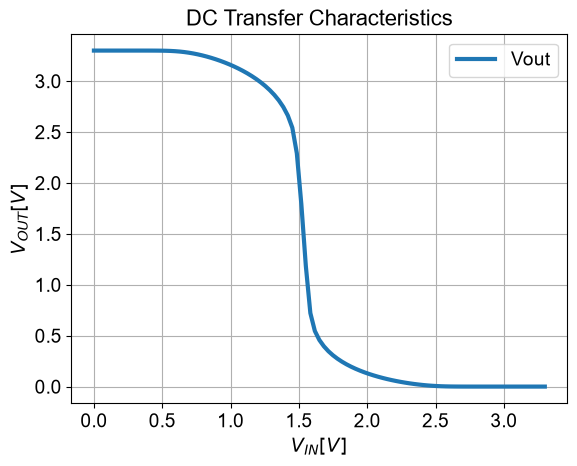

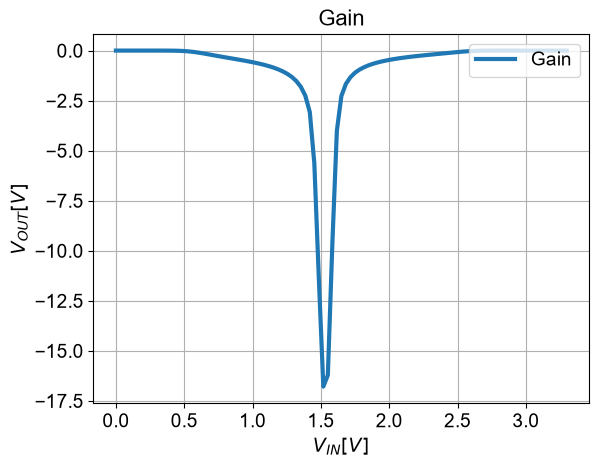

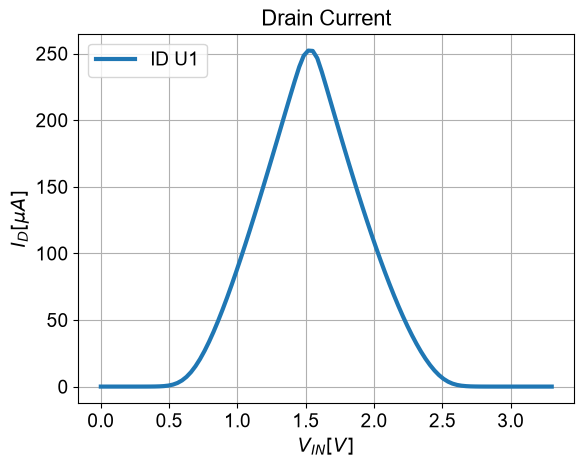

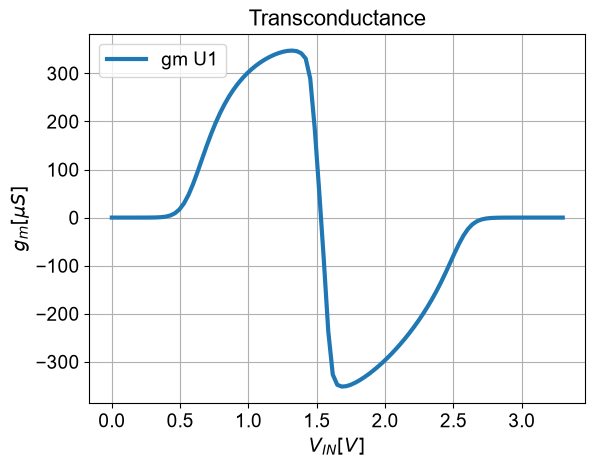

In [7]:
# --- Ruta a tu archivo .raw de LTspice ---
RAW_LTSPICE = "Inverter_DCSweep.raw"

# --- Lectura ---
raw = RawRead(RAW_LTSPICE)
# raw.get_trace_names()  # descomenta para ver todos los nombres disponibles

vin  = raw.get_trace("V3").get_wave()          # nodo de barrido (VIN)
vout = raw.get_trace("V(n1)").get_wave()       # salida del inversor
id_u1 = raw.get_trace("Ix(u1:d)").get_wave()    # corriente de drenador de U1 (NMOS)

# --- gm = dID/dVGS ---
# En este circuito VGS(U1) = VIN (la fuente de U1 está a 0V), así que
# derivamos ID respecto al mismo eje de barrido VIN.
# OJO: como VDS(U1)=VOUT también varía en este barrido, esta gm mezcla
# el efecto de VGS y VDS a lo largo de la curva de conmutación —
# no es la gm de pequeña señal a VDS constante.
gm_u1 = np.gradient(id_u1, vin)
gain = np.gradient(vout, vin)

# --- Gráficas ---
plt.plot(vin, vout, linewidth = 3, label='Vout')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('DC Transfer Characteristics', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{OUT} [V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(vin, gain, linewidth = 3, label='Gain')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('Gain', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{OUT} [V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(vin, id_u1 * 1e6, linewidth = 3, label='ID U1')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('Drain Current', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$I_{D} [µA]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(vin, gm_u1 * 1e6, linewidth = 3, label='gm U1')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('Transconductance', weight='normal',fontsize=16)
plt.xlabel(r'$V_{IN} [V]$',weight='normal',fontsize=14)
plt.ylabel(r'$g_m [µS]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

In [10]:
# ============================================================
# Punto de operación (Operating Point) — LTspice
# Lectura del .log con spicelib.opLogReader + tabla formateada
# ============================================================
LOG_LTSPICE = "Inverter_DCSweep.log"

# --- Lectura del log ---
op_data = opLogReader(LOG_LTSPICE)
mosfets = op_data["bsim4 mosfets"]   # dict: {nombre_transistor: {param: valor}}

devices = list(mosfets.keys())        # columnas -> transistores
params  = ["Id", "Vgs", "Vds", "Vbs", "Vth", "Vdsat",
           "Gm", "Gds", "Gmb", "Cbd", "Cbs"]   # filas -> parámetros

# --- Tabla: filas = parámetros, columnas = transistores ---
table = PrettyTable()
table.field_names = ["Parámetro"] + devices

for p in params:
    row = [p]
    for dev in devices:
        row.append(num2eng(mosfets[dev][p]))
    table.add_row(row)

print(f"Punto de operación — {LOG_LTSPICE}\n")
print(table)

Punto de operación — Inverter_DCSweep.log

+-----------+----------+----------+
| Parámetro | u1:x1:m0 | u2:x1:m0 |
+-----------+----------+----------+
|     Id    | 225.0 µ  | -225.0 µ |
|    Vgs    |   1.6    |  -1.6    |
|    Vds    | 458.0 m  |  -2.8    |
|    Vbs    |   0.0    |   0.0    |
|    Vth    | 651.0 m  | -707.0 m |
|   Vdsat   | 634.0 m  | -793.0 m |
|     Gm    | 229.0 µ  | 377.0 µ  |
|    Gds    | 267.0 µ  |  12.6 µ  |
|    Gmb    |  58.8 µ  | 128.0 µ  |
|    Cbd    |  1.3 f   |  1.7 f   |
|    Cbs    |  1.6 f   |  2.6 f   |
+-----------+----------+----------+
